---
title: "The Hutchinson trace estimator"
short_title: "01 · Hutchinson trace"
subtitle: "Why the log-det of a continuous flow is a trace, not a determinant — and how a random probe turns an O(d)-per-step exact trace into an O(1) stochastic estimate that lets free-form CNFs scale"
description: >
  A FFJORD's log-density is the time integral of tr(∂f/∂x). Computing that trace
  exactly costs one Jacobian-vector product per dimension; for images that is
  hopeless. Hutchinson's identity replaces the trace with z^T (∂f/∂x) z for a random
  probe z, an O(1)-per-step estimate. This notebook builds the estimator on a known
  matrix (unbiasedness, 1/sqrt(n) convergence, Rademacher vs Gaussian variance),
  then puts it inside gauss_flows' FFJORD: per-step divergence, the integrated
  log-det error vs probe count, why the probes are fixed per instance, and the O(d)
  vs O(n) cost scaling that is the whole point.
---

(sec-nb-ct-01)=
# 01 — The Hutchinson trace estimator

In [00 — FFJORD](00_ffjord_2d.ipynb) the log-density of a continuous flow was a
**line integral of the trace** of the Jacobian,

$$
\log p_0(x_0) = \log p_1(x_1) + \int_0^1 \operatorname{tr}\!\big(\partial_x f_\theta(t, x_t)\big)\,\mathrm{d}t .
$$

That trace is the continuous flow's entire log-det machinery — and it is what makes
CNFs scale or not. Computing $\operatorname{tr}(\partial_x f)$ **exactly** means
extracting the $d$ diagonal entries of the $d\times d$ Jacobian, which costs $d$
Jacobian-vector products (one per coordinate) *at every ODE step*. In 2-D that is
nothing; for a $32\times32\times3$ image ($d=3072$) it is $3072$ JVPs per step per
sample — hopeless.

**Hutchinson's identity** {cite}`hutchinson1990` rescues it. For any random vector
$z$ with $\mathbb{E}[z z^\top] = I$,

$$
\operatorname{tr}(A) = \mathbb{E}_z\big[z^\top A z\big],
$$

so a *single* probe gives an unbiased estimate of the trace from one
Jacobian-vector product $Az = (\partial_x f)\,z$ — $O(1)$ per step instead of
$O(d)$. The price is variance: the estimate is noisy, shrinking as
$1/\sqrt{n}$ in the number of probes $n$. This is the trade FFJORD
{cite}`grathwohl2019ffjord` makes to train free-form vector fields at scale.

**What you will see**

- Hutchinson on a **known matrix**: unbiasedness and $1/\sqrt{n}$ convergence.
- **Rademacher vs Gaussian** probes and the variance formulas — why Rademacher wins.
- The estimator **inside FFJORD**: per-step divergence and the integrated-log-det
  error vs probe count, on a real `gf.FFJORD`.
- Why the probes are **fixed per instance** (deterministic log-det → stable training).
- The **$O(d)$ vs $O(n)$** cost scaling — the reason continuous flows scale.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data

import gauss_flows as gf
from gauss_flows._src._divergence import exact_divergence, hutchinson_divergence
from _style import DATA_COLOR, GAUSS_KW, LATENT_COLOR, style_ax

jax.config.update("jax_enable_x64", True)

## 1. Hutchinson on a known matrix

Strip away the flow and look at the estimator on a fixed matrix $A$ where we know
the answer. With $z$ a random sign vector (Rademacher, $z_i\in\{\pm1\}$),
$z^\top A z = \sum_{i,j} A_{ij} z_i z_j$. Taking expectations, the off-diagonal
terms vanish ($\mathbb{E}[z_i z_j]=0$ for $i\ne j$) and the diagonal terms survive
($z_i^2 = 1$), leaving exactly $\sum_i A_{ii} = \operatorname{tr}(A)$. The
$n$-probe estimator averages $n$ such draws.

In [2]:
d = 24
key = jr.key(0)
A_key, _ = jr.split(key)
# A symmetric matrix with a known trace.
M = jr.normal(A_key, (d, d))
A = 0.5 * (M + M.T)
tr_exact = float(jnp.trace(A))


def hutch_estimate(A, Z):
    """n-probe Hutchinson estimate from probes Z of shape (n, d): mean_k z_k^T A z_k."""
    return jnp.mean(jnp.sum((Z @ A) * Z, axis=1))


def rademacher(key, n, d):
    return jnp.sign(jr.normal(key, (n, d)))


# One probe at a time: unbiased but noisy.
single = jnp.array([hutch_estimate(A, rademacher(jr.key(s), 1, d)) for s in range(2000)])
print(f"exact trace                         = {tr_exact:+.4f}")
print(f"mean of 2000 single-probe estimates = {float(single.mean()):+.4f}  (unbiased)")
print(f"std  of single-probe estimates      = {float(single.std()):.4f}   (the noise to beat)")

exact trace                         = -2.7480
mean of 2000 single-probe estimates = -2.8666  (unbiased)


std  of single-probe estimates      = 21.7016   (the noise to beat)


The single-probe estimate is centered on the true trace but scatters widely. The
$n$-probe estimator averages that noise down. We sweep $n$ and measure the RMSE
over many independent estimators, expecting the classic Monte-Carlo $1/\sqrt{n}$.

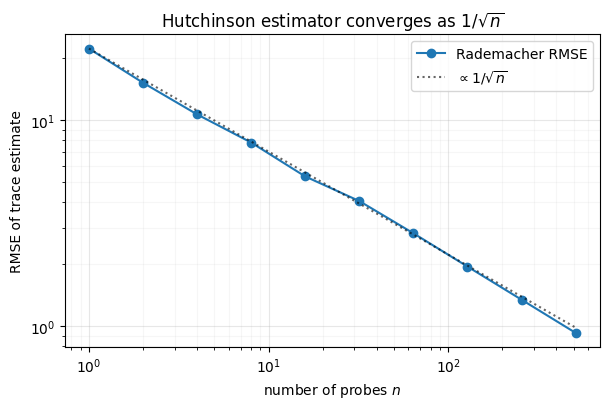

In [3]:
probe_counts = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512])
n_trials = 400


def rmse_vs_n(sampler):
    out = []
    for i, n in enumerate(probe_counts):
        ests = jnp.array([
            hutch_estimate(A, sampler(jr.key(1000 * i + t), int(n), d))
            for t in range(n_trials)
        ])
        out.append(float(jnp.sqrt(jnp.mean((ests - tr_exact) ** 2))))
    return np.array(out)


rmse_rad = rmse_vs_n(rademacher)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(probe_counts, rmse_rad, "o-", color=DATA_COLOR, label="Rademacher RMSE")
ref = rmse_rad[0] / np.sqrt(probe_counts / probe_counts[0])
ax.loglog(probe_counts, ref, "k:", alpha=0.6, label=r"$\propto 1/\sqrt{n}$")
ax.set(xlabel="number of probes $n$", ylabel="RMSE of trace estimate",
       title="Hutchinson estimator converges as $1/\\sqrt{n}$")
ax.legend()
style_ax(ax)
fig.tight_layout()

The RMSE rides the $1/\sqrt{n}$ reference exactly: quadrupling the probes halves the
error. There is no bias to worry about — only this variance, which is why the probe
**distribution** matters.

## 2. Rademacher vs Gaussian probes

Any $z$ with $\mathbb{E}[zz^\top]=I$ works, but they do not all have the same
variance. For a **symmetric** $A$,

$$
\operatorname{Var}_{\mathcal{N}}\!\big[z^\top A z\big] = 2\,\lVert A\rVert_F^2,
\qquad
\operatorname{Var}_{\text{Rad}}\!\big[z^\top A z\big] = 2\Big(\lVert A\rVert_F^2 - \textstyle\sum_i A_{ii}^2\Big).
$$

The Rademacher variance is the Gaussian variance *minus* the diagonal's
contribution: because $z_i^2=1$ is deterministic for sign probes, the diagonal of
$A$ (which is exactly what we are summing) carries **no** variance. That makes
Rademacher the minimum-variance probe {cite}`hutchinson1990`, and the default in
`gauss_flows`. We verify both formulas.

       probe   empirical var       formula


  rademacher         486.031       483.506


      normal         532.999       540.290

(the diagonal adds 2*sum(A_ii^2) = 56.8 to the Gaussian variance; Rademacher avoids it entirely)


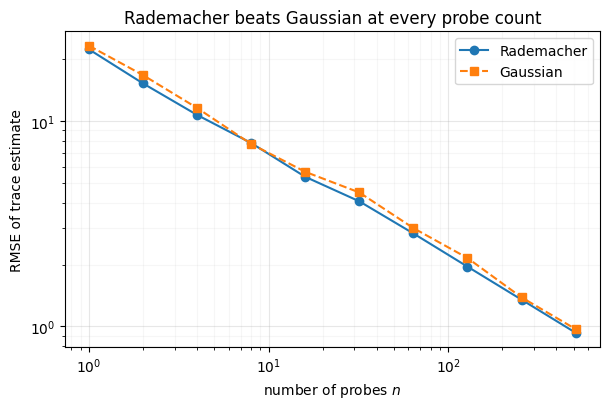

In [4]:
def gaussian(key, n, d):
    return jr.normal(key, (n, d))


fro2 = float(jnp.sum(A**2))
diag2 = float(jnp.sum(jnp.diag(A) ** 2))
var_formula = {"rademacher": 2 * (fro2 - diag2), "normal": 2 * fro2}

print(f"{'probe':>12s}  {'empirical var':>14s}  {'formula':>12s}")
for name, sampler in (("rademacher", rademacher), ("normal", gaussian)):
    s = jnp.array([hutch_estimate(A, sampler(jr.key(t), 1, d)) for t in range(4000)])
    print(f"{name:>12s}  {float(s.var()):>14.3f}  {var_formula[name]:>12.3f}")
print(f"\n(the diagonal adds 2*sum(A_ii^2) = {2 * diag2:.1f} to the Gaussian variance; "
      f"Rademacher avoids it entirely)")

rmse_norm = rmse_vs_n(gaussian)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(probe_counts, rmse_rad, "o-", color=DATA_COLOR, label="Rademacher")
ax.loglog(probe_counts, rmse_norm, "s--", color=LATENT_COLOR, label="Gaussian")
ax.set(xlabel="number of probes $n$", ylabel="RMSE of trace estimate",
       title="Rademacher beats Gaussian at every probe count")
ax.legend()
style_ax(ax)
fig.tight_layout()

The empirical variances match the formulas, and Rademacher sits below Gaussian at
every $n$ — same cost, less noise. (For a *general* non-symmetric $A$, as the flow
Jacobian will be, the constants change but Rademacher's diagonal-is-free advantage
remains.)

## 3. The estimator inside FFJORD

Now the matrix is the flow Jacobian $A = \partial_x f_\theta(t, x)$ and the probe
product $Az$ is a single forward-mode JVP. `gauss_flows` exposes both routes
directly — `exact_divergence` (via `jax.jacfwd`, the full trace) and
`hutchinson_divergence` (the estimator). We train a small FFJORD on a $6$-D
non-Gaussian toy (a smooth warp of a Gaussian) and compare the two routes at the
data points. We use a *few* dimensions on purpose: in $d=2$ there are only four
Rademacher probes and a complementary pair recovers the trace exactly, so the
estimator is degenerate — by $d=6$ it behaves like the general case. The fit is kept
brief; this notebook is about the estimator, not the density.

In [5]:
D = 6
zc = jr.normal(jr.key(1), (1500, D))
Q = jnp.linalg.qr(jr.normal(jr.key(2), (D, D)))[0]
Xr = (zc + 0.6 * jnp.sin(2.0 * zc)) @ Q.T        # smooth non-Gaussian warp + mixing
X = (Xr - Xr.mean(0)) / Xr.std(0)

vf_key, ff_key, train_key = jr.split(jr.key(0), 3)
ffjord = gf.FFJORD(
    ff_key, shape=(D,),
    vector_field=gf.DiffeqMLP(vf_key, in_dim=D, control_dim=0, hidden=(64, 64)),
    control_dim=0, divergence_mode="exact", solver="tsit5",
    adjoint="recursive_checkpoint", rtol=1e-4, atol=1e-4,
)
steps = -(-int(X.shape[0] * 0.9) // 256)
lr = optax.cosine_decay_schedule(2e-3, decay_steps=60 * steps, alpha=0.02)
trained_dist, _ = fit_to_data(
    train_key, Transformed(Normal(jnp.zeros(D)), ffjord), X,
    optimizer=optax.chain(optax.clip_by_global_norm(5.0), optax.adam(lr)),
    max_epochs=60, max_patience=15, batch_size=256, val_prop=0.1, show_progress=False,
)
vf = trained_dist.bijection.vector_field
print(f"trained a small {D}-D FFJORD (60 epochs) to get a non-trivial vector field")

trained a small 6-D FFJORD (60 epochs) to get a non-trivial vector field


At a fixed time $t=0.5$ we evaluate, for each data point, the **exact** divergence
$\operatorname{tr}(\partial_x f)$ and the **Hutchinson** estimate with $1$ and $16$
probes. Plotting estimate against exact, a perfect estimator lies on $y=x$; the
single-probe cloud is wide, the 16-probe cloud collapses onto the line.

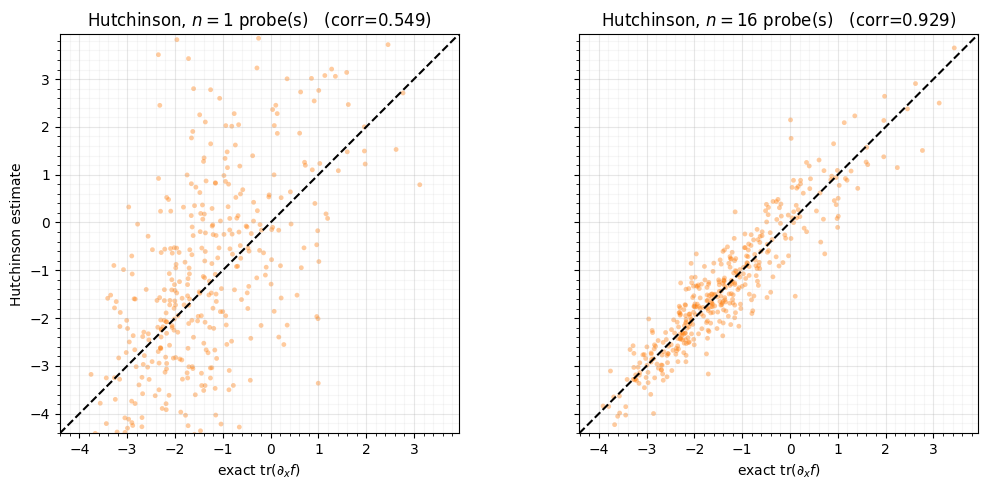

In [6]:
t_eval = 0.5
pts = X[:400]
div_exact = jax.vmap(lambda x: exact_divergence(vf, t_eval, x, None))(pts)


def hutch_at(pts, n, seed):
    keys = jr.split(jr.key(seed), pts.shape[0])
    return jax.vmap(
        lambda x, k: hutchinson_divergence(vf, t_eval, x, None, key=k, n_samples=n)
    )(pts, keys)


fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lo, hi = float(div_exact.min()) - 0.5, float(div_exact.max()) + 0.5
for ax, n in zip(axes, (1, 16)):
    est = hutch_at(pts, n, seed=7)
    ax.scatter(np.asarray(div_exact), np.asarray(est), color=LATENT_COLOR,
               s=12, alpha=0.4, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], **GAUSS_KW)
    corr = float(jnp.corrcoef(div_exact, est)[0, 1])
    ax.set(title=f"Hutchinson, $n={n}$ probe(s)   (corr={corr:.3f})",
           xlabel=r"exact $\mathrm{tr}(\partial_x f)$", xlim=(lo, hi), ylim=(lo, hi))
    ax.set_aspect("equal")
    style_ax(ax)
axes[0].set_ylabel("Hutchinson estimate")
fig.tight_layout()

## 4. The integrated log-determinant

Per-step noise is one thing; what we actually train on is the **integrated**
log-det over the whole ODE. The trace estimate enters the augmented dynamics at
every solver step, so the errors integrate. We hold the trained vector field fixed,
rebuild FFJORD in `exact` mode (the reference) and in `hutchinson` mode at several
probe counts, and measure the error of $\log p_\theta(x)$ on a held-out batch — the
proper version of the quick check from notebook 00. Each FFJORD fixes one probe set,
so we average the error over several independent probe draws: the curve then traces
the estimator's behaviour rather than one lucky (or unlucky) draw.

exact mean log p = -7.5548  (each row averaged over 6 probe draws)

 n_probes       bias       RMSE


        1    +0.1236     2.2566


        2    -0.0415     0.8920


        4    +0.0728     1.1628


        8    -0.0771     0.7785


       16    -0.0400     0.5187


       32    +0.0247     0.3847


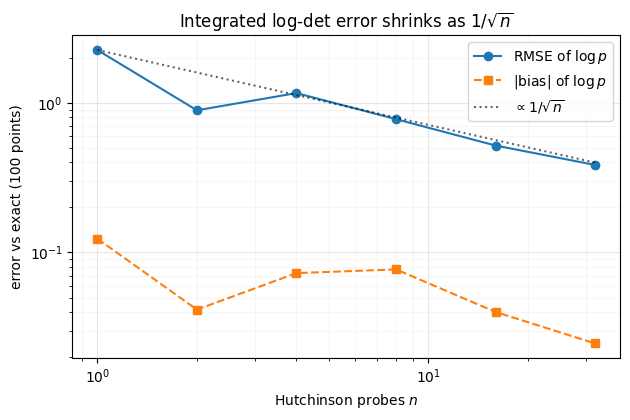

In [7]:
eval_pts = X[:100]
exact_flow = gf.FFJORD(
    jr.key(0), shape=(D,), vector_field=vf, control_dim=0,
    divergence_mode="exact", solver="tsit5", adjoint="direct", rtol=1e-6, atol=1e-6,
)
exact_lp = jax.vmap(Transformed(Normal(jnp.zeros(D)), exact_flow).log_prob)(eval_pts)


def hutch_errors(n, seed):
    """Per-point log p error vs exact, for one fixed probe set."""
    flow = gf.FFJORD(
        jr.key(seed), shape=(D,), vector_field=vf, control_dim=0,
        divergence_mode="hutchinson", n_hutchinson_samples=n,
        solver="tsit5", adjoint="direct", rtol=1e-5, atol=1e-5,
    )
    lp = jax.vmap(Transformed(Normal(jnp.zeros(D)), flow).log_prob)(eval_pts)
    return lp - exact_lp


ns = np.array([1, 2, 4, 8, 16, 32])
n_realizations = 6
biases, rmses = [], []
print(f"exact mean log p = {float(jnp.mean(exact_lp)):+.4f}  "
      f"(each row averaged over {n_realizations} probe draws)\n")
print(f"{'n_probes':>9s}  {'bias':>9s}  {'RMSE':>9s}")
for i, n in enumerate(ns):
    errs = jnp.stack([hutch_errors(int(n), seed=37 * i + 1000 * s + 1)
                      for s in range(n_realizations)])
    b = float(jnp.mean(errs)); r = float(jnp.sqrt(jnp.mean(errs**2)))
    biases.append(b); rmses.append(r)
    print(f"{int(n):>9d}  {b:>+9.4f}  {r:>9.4f}")

fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.loglog(ns, rmses, "o-", color=DATA_COLOR, label="RMSE of $\\log p$")
ax.loglog(ns, np.abs(biases), "s--", color=LATENT_COLOR, label="|bias| of $\\log p$")
ax.loglog(ns, rmses[0] / np.sqrt(ns / ns[0]), "k:", alpha=0.6, label=r"$\propto 1/\sqrt{n}$")
ax.set(xlabel="Hutchinson probes $n$", ylabel="error vs exact (100 points)",
       title="Integrated log-det error shrinks as $1/\\sqrt{n}$")
ax.legend()
style_ax(ax)
fig.tight_layout()

The per-point RMSE follows $1/\sqrt{n}$, while the **bias** (the error in the
*mean* log-density) is far smaller — averaging across points cancels the
zero-mean per-point noise. So a small probe count gives a trustworthy *dataset*
NLL, but per-point values (anomaly scores, OOD detection) want more probes or the
exact trace.

## 5. Why the probes are fixed per instance

A subtle but important choice: `gauss_flows` draws the Hutchinson probes **once**
at construction (from the FFJORD's `trace_key`) and reuses them across every call
*and every ODE step* — the "fixed-noise" variant {cite}`grathwohl2019ffjord`. The
alternative, resampling probes each step, would make $\log p_\theta(x)$ a random
function of $x$, injecting noise into every gradient and destabilising training.
Fixing the probes makes the log-det a **deterministic** function of the parameters,
so the optimiser sees a consistent objective. We confirm the determinism.

In [8]:
fixed = gf.FFJORD(jr.key(0), shape=(D,), vector_field=vf, control_dim=0,
                  divergence_mode="hutchinson", n_hutchinson_samples=4,
                  solver="tsit5", adjoint="direct")
x0 = eval_pts[0]
ld_a = float(fixed.transform_and_log_det(x0)[1])
ld_b = float(fixed.transform_and_log_det(x0)[1])
other = gf.FFJORD(jr.key(123), shape=(D,), vector_field=vf, control_dim=0,
                  divergence_mode="hutchinson", n_hutchinson_samples=4,
                  solver="tsit5", adjoint="direct")
ld_c = float(other.transform_and_log_det(x0)[1])
print("same instance, two calls   :", f"{ld_a:+.6f}", "==", f"{ld_b:+.6f}",
      "->", "identical" if ld_a == ld_b else "DIFFER")
print("different trace_key instance:", f"{ld_c:+.6f}",
      "-> differs (a different fixed probe set)")
print("\nFixed probes => log_det is a deterministic function of params => stable gradients.")

same instance, two calls   : -2.140167 == -2.140167 -> identical
different trace_key instance: +1.115355 -> differs (a different fixed probe set)

Fixed probes => log_det is a deterministic function of params => stable gradients.


Calling the same flow twice gives a bit-identical log-det; a flow with a different
`trace_key` gives a different (but still unbiased) value. During training you keep
one instance, so the objective is fixed.

## 6. The cost that makes it worth it — $O(d)$ vs $O(n)$

The exact trace needs $d$ Jacobian-vector products per ODE step (one per
coordinate); Hutchinson needs $n$, *independent of $d$*. As $d$ grows, the exact
cost climbs linearly while a fixed-probe Hutchinson stays flat. We time a single
divergence evaluation of a `DiffeqMLP` across dimensions.

   dim   exact (ms)   hutch n=1 (ms)   JVPs: exact / hutch
     2        0.243            0.183                 2 / 1
     8        0.324            0.226                 8 / 1
    32        0.233            0.221                32 / 1
   128        0.578            0.259               128 / 1
   512        3.430            0.215               512 / 1


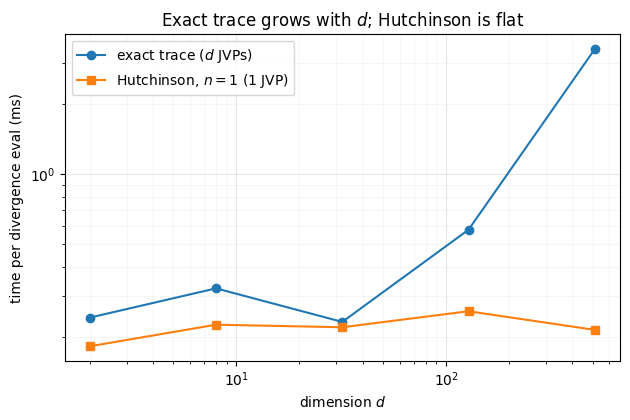

In [9]:
def bench(fn, x, reps=25):
    fn(x).block_until_ready()  # warm up / compile
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(x).block_until_ready()
    return (time.perf_counter() - t0) / reps * 1e3  # ms


dims = [2, 8, 32, 128, 512]
t_exact, t_hutch = [], []
for dim in dims:
    vfd = gf.DiffeqMLP(jr.key(dim), in_dim=dim, control_dim=0, hidden=(64, 64))
    xd = jr.normal(jr.key(dim + 1), (dim,))
    f_ex = eqx.filter_jit(lambda x, vfd=vfd: exact_divergence(vfd, 0.5, x, None))
    f_hu = eqx.filter_jit(
        lambda x, vfd=vfd: hutchinson_divergence(vfd, 0.5, x, None, key=jr.key(0), n_samples=1)
    )
    t_exact.append(bench(f_ex, xd))
    t_hutch.append(bench(f_hu, xd))

print(f"{'dim':>6s}  {'exact (ms)':>11s}  {'hutch n=1 (ms)':>15s}  {'JVPs: exact / hutch':>20s}")
for dim, te, th in zip(dims, t_exact, t_hutch):
    print(f"{dim:>6d}  {te:>11.3f}  {th:>15.3f}  {f'{dim} / 1':>20s}")

fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.loglog(dims, t_exact, "o-", color=DATA_COLOR, label="exact trace ($d$ JVPs)")
ax.loglog(dims, t_hutch, "s-", color=LATENT_COLOR, label="Hutchinson, $n=1$ (1 JVP)")
ax.set(xlabel="dimension $d$", ylabel="time per divergence eval (ms)",
       title="Exact trace grows with $d$; Hutchinson is flat")
ax.legend()
style_ax(ax)
fig.tight_layout()

Exact divergence climbs with $d$ (its $d$ JVPs show up as a rising line); the
single-probe estimate stays roughly flat. The lines cross at small $d$ — which is
exactly why notebook [00](00_ffjord_2d.ipynb) used the **exact** trace in 2-D and
this notebook matters for everything bigger. For image-scale $d\sim10^3$–$10^6$,
the exact trace is simply not an option and Hutchinson is the only way the log-det
is computable at all.

## Recap

| | exact trace | Hutchinson estimator |
|---|---|---|
| cost / ODE step | $O(d)$ JVPs | $O(n)$ JVPs, $n$ fixed |
| error | none | unbiased, RMSE $\propto 1/\sqrt{n}$ |
| best probe | — | Rademacher (diagonal variance-free) |
| probes | — | **fixed** per instance → deterministic log-det |
| use when | small $d$ / validation | large $d$ / training |

Hutchinson is the hinge that turns the elegant trace integral of notebook 00 into a
method that runs on images and high-dimensional fields: trade a little variance for
an $O(1)$-per-step log-det, pick Rademacher probes, fix them so training is stable.

**Next up.** Not every continuous flow needs a stochastic trace. [02 —
Matrix-exponential neural flow](02_matrix_exponential_flow.ipynb) takes a *linear*
ODE $\dot x = Ax$, whose flow map is $\exp(At)$ and whose log-det is the **exact,
closed-form** $t\,\operatorname{tr}(A)$ — no estimator, no integration.